In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv('/content/world_bank_Import_Usd_enriched - Copy.csv')

In [ ]:
df

,Country,Year,Imports_Current_USD,Continent,Subregion,Income_Group,Development_Status,Geo_Cluster
0,Afghanistan,2024,NaN,Asia,South Asia,Low income,Developing,Asia_Low income
1,Afghanistan,2023,"8,701,650,584.05",Asia,South Asia,Low income,Developing,Asia_Low income
2,Afghanistan,2022,"7,901,784,705.75",Asia,South Asia,Low income,Developing,Asia_Low income
3,Afghanistan,2021,"5,286,118,076.13",Asia,South Asia,Low income,Developing,Asia_Low income
4,Afghanistan,2020,"7,241,822,542.18",Asia,South Asia,Low income,Developing,Asia_Low income
...,...,...,...,...,...,...,...,...
11062,Zimbabwe,1978,"870,131,045.28",Africa,East Africa,Lower middle income,Developing,Africa_Lower middle income
11063,Zimbabwe,1977,"882,823,922.70",Africa,East Africa,Lower middle income,Developing,Africa_Lower middle income
11064,Zimbabwe,1976,"846,707,691.87",Africa,East Africa,Lower middle income,Developing,Africa_Lower middle income
11065,Zimbabwe,1975,"1,068,612,734.45",Africa,East Africa,Lower middle income,Developing,Africa_Lower middle income


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11067 entries, 0 to 11066
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Country                11067 non-null  object
 1   Year                   11067 non-null  int64 
 2    Imports_Current_USD   7763 non-null   object
 3   Continent              11067 non-null  object
 4   Subregion              11067 non-null  object
 5   Income_Group           11067 non-null  object
 6   Development_Status     11067 non-null  object
 7   Geo_Cluster            11067 non-null  object
dtypes: int64(1), object(7)
memory usage: 691.8+ KB


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Faylni o'qish
df = pd.read_csv('/content/world_bank_Import_Usd_enriched - Copy.csv')

# ✅ Ustun nomlaridagi bo'sh joylarni tozalash
df.columns = df.columns.str.strip()

# Tekshirish
print("Ustun nomlari:")
print(df.columns.tolist())

Ustun nomlari:
['Country', 'Year', 'Imports_Current_USD', 'Continent', 'Subregion', 'Income_Group', 'Development_Status', 'Geo_Cluster']


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════
# 1. FAYLNI O'QISH VA USTUN NOMLARINI TOZALASH
# ════════════════════════════════════════
df = pd.read_csv('/content/world_bank_Import_Usd_enriched - Copy.csv')

# Ustun nomlaridagi probel va ortiqcha bo'sh joylarni olib tashlaymiz
df.columns = df.columns.str.strip()

print("✅ Ustun nomlari (tozalangandan keyin):")
for i, col in enumerate(df.columns):
    print(f"   {i}. '{col}'")

# ════════════════════════════════════════
# 2. HAR BIR USTUN TURINI ANIQLASH
# ════════════════════════════════════════
print("\n" + "="*55)
print("📋 USTUNLAR TAHLILI")
print("="*55)

for col in df.columns:
    dtype = df[col].dtype
    nulls = df[col].isnull().sum()
    unique = df[col].nunique()
    print(f"\n🔹 '{col}'")
    print(f"   Turi    : {dtype}")
    print(f"   Bo'sh   : {nulls} ta ({nulls/len(df)*100:.1f}%)")
    print(f"   Unique  : {unique} ta")
    if dtype == 'object':
        print(f"   Namuna  : {df[col].dropna().unique()[:3].tolist()}")

# ════════════════════════════════════════
# 3. RAQAMLI USTUNNI TO'G'RI TURGA O'TKAZISH
#    (Imports_Current_USD object holida kelgan)
# ════════════════════════════════════════
print("\n" + "="*55)
print("🔧 IMPORTS_CURRENT_USD USTUNINI TOZALASH")
print("="*55)

df['Imports_Current_USD'] = (
    df['Imports_Current_USD']
    .astype(str)
    .str.strip()
    .str.replace(',', '', regex=False)
    .replace({'nan': np.nan, 'NaN': np.nan, '': np.nan})
)
df['Imports_USD'] = pd.to_numeric(df['Imports_Current_USD'], errors='coerce')

nan_count = df['Imports_USD'].isnull().sum()
zero_count = (df['Imports_USD'] == 0).sum()
print(f"   NaN qatorlar : {nan_count} ta")
print(f"   0 qiymatlar  : {zero_count} ta")

# ════════════════════════════════════════
# 4. BO'SH QIYMATLARNI TO'LDIRISH STRATEGIYASI
#    ⚠️ Data analitik fikri:
#    - NaN = ma'lumot yo'q (sababsiz 0 qo'ymaslik kerak)
#    - Shuning uchun 3 variant ko'rsatamiz
# ════════════════════════════════════════
print("\n" + "="*55)
print("💡 BO'SH QIYMATLARNI TO'LDIRISH VARIANTLARI")
print("="*55)

median_val = df['Imports_USD'].median()
mean_val   = df['Imports_USD'].mean()

print(f"\n   Variant 1 → 0 bilan to'ldirish")
print(f"             (agar mamlakat haqiqatan import qilmagan bo'lsa)")
print(f"\n   Variant 2 → Median bilan to'ldirish: ${median_val:,.0f}")
print(f"             (statistik ta'sirni kamaytiradi, outlier xavfsiz)")
print(f"\n   Variant 3 → Mean bilan to'ldirish: ${mean_val:,.0f}")
print(f"             (outlier bo'lsa xato berishi mumkin)")
print(f"\n   Variant 4 → NaN saqlab qolish + flag ustun qo'shish ✅ TAVSIYA")

# ════════════════════════════════════════
# 5. TAVSIYA ETILGAN YONDASHUV
#    NaN ni saqlaymiz, lekin flag ustun qo'shamiz
# ════════════════════════════════════════

# Flag: ma'lumot bor yoki yo'qligini belgilaydi
df['Import_Data_Available'] = df['Imports_USD'].notna().astype(int)
# 1 = ma'lumot bor, 0 = ma'lumot yo'q

print("\n✅ 'Import_Data_Available' ustuni qo'shildi:")
print(df['Import_Data_Available'].value_counts().rename({1: 'Ma\'lumot bor', 0: 'Ma\'lumot yo\'q'}))

# ════════════════════════════════════════
# 6. MATNLI USTUNLARNI TOZALASH
# ════════════════════════════════════════
print("\n" + "="*55)
print("🔤 MATNLI USTUNLARNI TOZALASH")
print("="*55)

text_cols = df.select_dtypes(include='object').columns.tolist()

for col in text_cols:
    before = df[col].isnull().sum()
    df[col] = df[col].str.strip()           # probel olib tashlash
    df[col] = df[col].str.title()           # Har so'z bosh harf
    df[col].fillna('Unknown', inplace=True) # Bo'sh → Unknown
    after = df[col].isnull().sum()
    print(f"   '{col}': {before} bo'sh → to'ldirildi ✅")

# ════════════════════════════════════════
# 7. DUPLICATE QATORLARNI TEKSHIRISH
# ════════════════════════════════════════
print("\n" + "="*55)
print("🔍 DUPLICATE QATORLAR TEKSHIRUVI")
print("="*55)

dup_count = df.duplicated().sum()
print(f"   Takroriy qatorlar: {dup_count} ta")

if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"   ✅ Duplicate qatorlar o'chirildi. Yangi hajm: {df.shape}")
else:
    print("   ✅ Duplicate yo'q — barchasi yaxshi")

# ════════════════════════════════════════
# 8. YAKUNIY HISOBOT
# ════════════════════════════════════════
print("\n" + "="*55)
print("📊 YAKUNIY TOZALANGAN DATASET HISOBOTI")
print("="*55)
print(f"   Qatorlar       : {df.shape[0]:,}")
print(f"   Ustunlar       : {df.shape[1]}")
print(f"   Jami bo'sh     : {df.isnull().sum().sum()} ta")
print(f"   Yillar         : {df['Year'].min()} – {df['Year'].max()}")
print(f"   Mamlakatlar    : {df['Country'].nunique()} ta")
print(f"\n✅ Dataset tahlilga tayyor!")
df.head()

✅ Ustun nomlari (tozalangandan keyin):
   0. 'Country'
   1. 'Year'
   2. 'Imports_Current_USD'
   3. 'Continent'
   4. 'Subregion'
   5. 'Income_Group'
   6. 'Development_Status'
   7. 'Geo_Cluster'

📋 USTUNLAR TAHLILI

🔹 'Country'
   Turi    : object
   Bo'sh   : 0 ta (0.0%)
   Unique  : 217 ta
   Namuna  : ['Afghanistan', 'Albania', 'Algeria']

🔹 'Year'
   Turi    : int64
   Bo'sh   : 0 ta (0.0%)
   Unique  : 51 ta

🔹 'Imports_Current_USD'
   Turi    : object
   Bo'sh   : 3304 ta (29.9%)
   Unique  : 7758 ta
   Namuna  : [' 8,701,650,584.05 ', ' 7,901,784,705.75 ', ' 5,286,118,076.13 ']

🔹 'Continent'
   Turi    : object
   Bo'sh   : 0 ta (0.0%)
   Unique  : 6 ta
   Namuna  : ['Asia', 'Europe', 'Africa']

🔹 'Subregion'
   Turi    : object
   Bo'sh   : 0 ta (0.0%)
   Unique  : 24 ta
   Namuna  : ['South Asia', 'Southern Europe', 'North Africa']

🔹 'Income_Group'
   Turi    : object
   Bo'sh   : 0 ta (0.0%)
   Unique  : 4 ta
   Namuna  : ['Low income', 'Upper middle income', 'Lower mi

,Country,Year,Imports_Current_USD,Continent,Subregion,Income_Group,Development_Status,Geo_Cluster,Imports_USD,Import_Data_Available
0,Afghanistan,2024,Unknown,Asia,South Asia,Low Income,Developing,Asia_Low Income,NaN,0
1,Afghanistan,2023,8701650584.05,Asia,South Asia,Low Income,Developing,Asia_Low Income,8.701651e+09,1
2,Afghanistan,2022,7901784705.75,Asia,South Asia,Low Income,Developing,Asia_Low Income,7.901785e+09,1
3,Afghanistan,2021,5286118076.13,Asia,South Asia,Low Income,Developing,Asia_Low Income,5.286118e+09,1
4,Afghanistan,2020,7241822542.18,Asia,South Asia,Low Income,Developing,Asia_Low Income,7.241823e+09,1


📐 1. PEARSON KORRELYATSIYASI (Raqam ↔ Raqam)
               Year  Imports_USD
Year         1.0000       0.1978
Imports_USD  0.1978       1.0000

📊 2. POINT-BISERIAL KORRELYATSIYA (Raqam ↔ Kategorik)

  Continent:
    r = -0.0651 | p = 0.000000 | ✅ Muhim

  Subregion:
    r = 0.0363 | p = 0.001383 | ✅ Muhim

  Income_Group:
    r = 0.1985 | p = 0.000000 | ✅ Muhim

  Development_Status:
    r = 0.3134 | p = 0.000000 | ✅ Muhim

  Geo_Cluster:
    r = -0.0713 | p = 0.000000 | ✅ Muhim

🔗 3. CRAMÉR'S V KORRELYATSIYA (Kategorik ↔ Kategorik)
                    Continent  Subregion  Income_Group  Development_Status  \
Continent              1.0000     1.0000        0.4682              0.6858   
Subregion              1.0000     1.0000        0.6112              0.8348   
Income_Group           0.4682     0.6112        1.0000              0.7090   
Development_Status     0.6858     0.8348        0.7090              0.9997   
Geo_Cluster            1.0000     0.6047        1.0000              0.

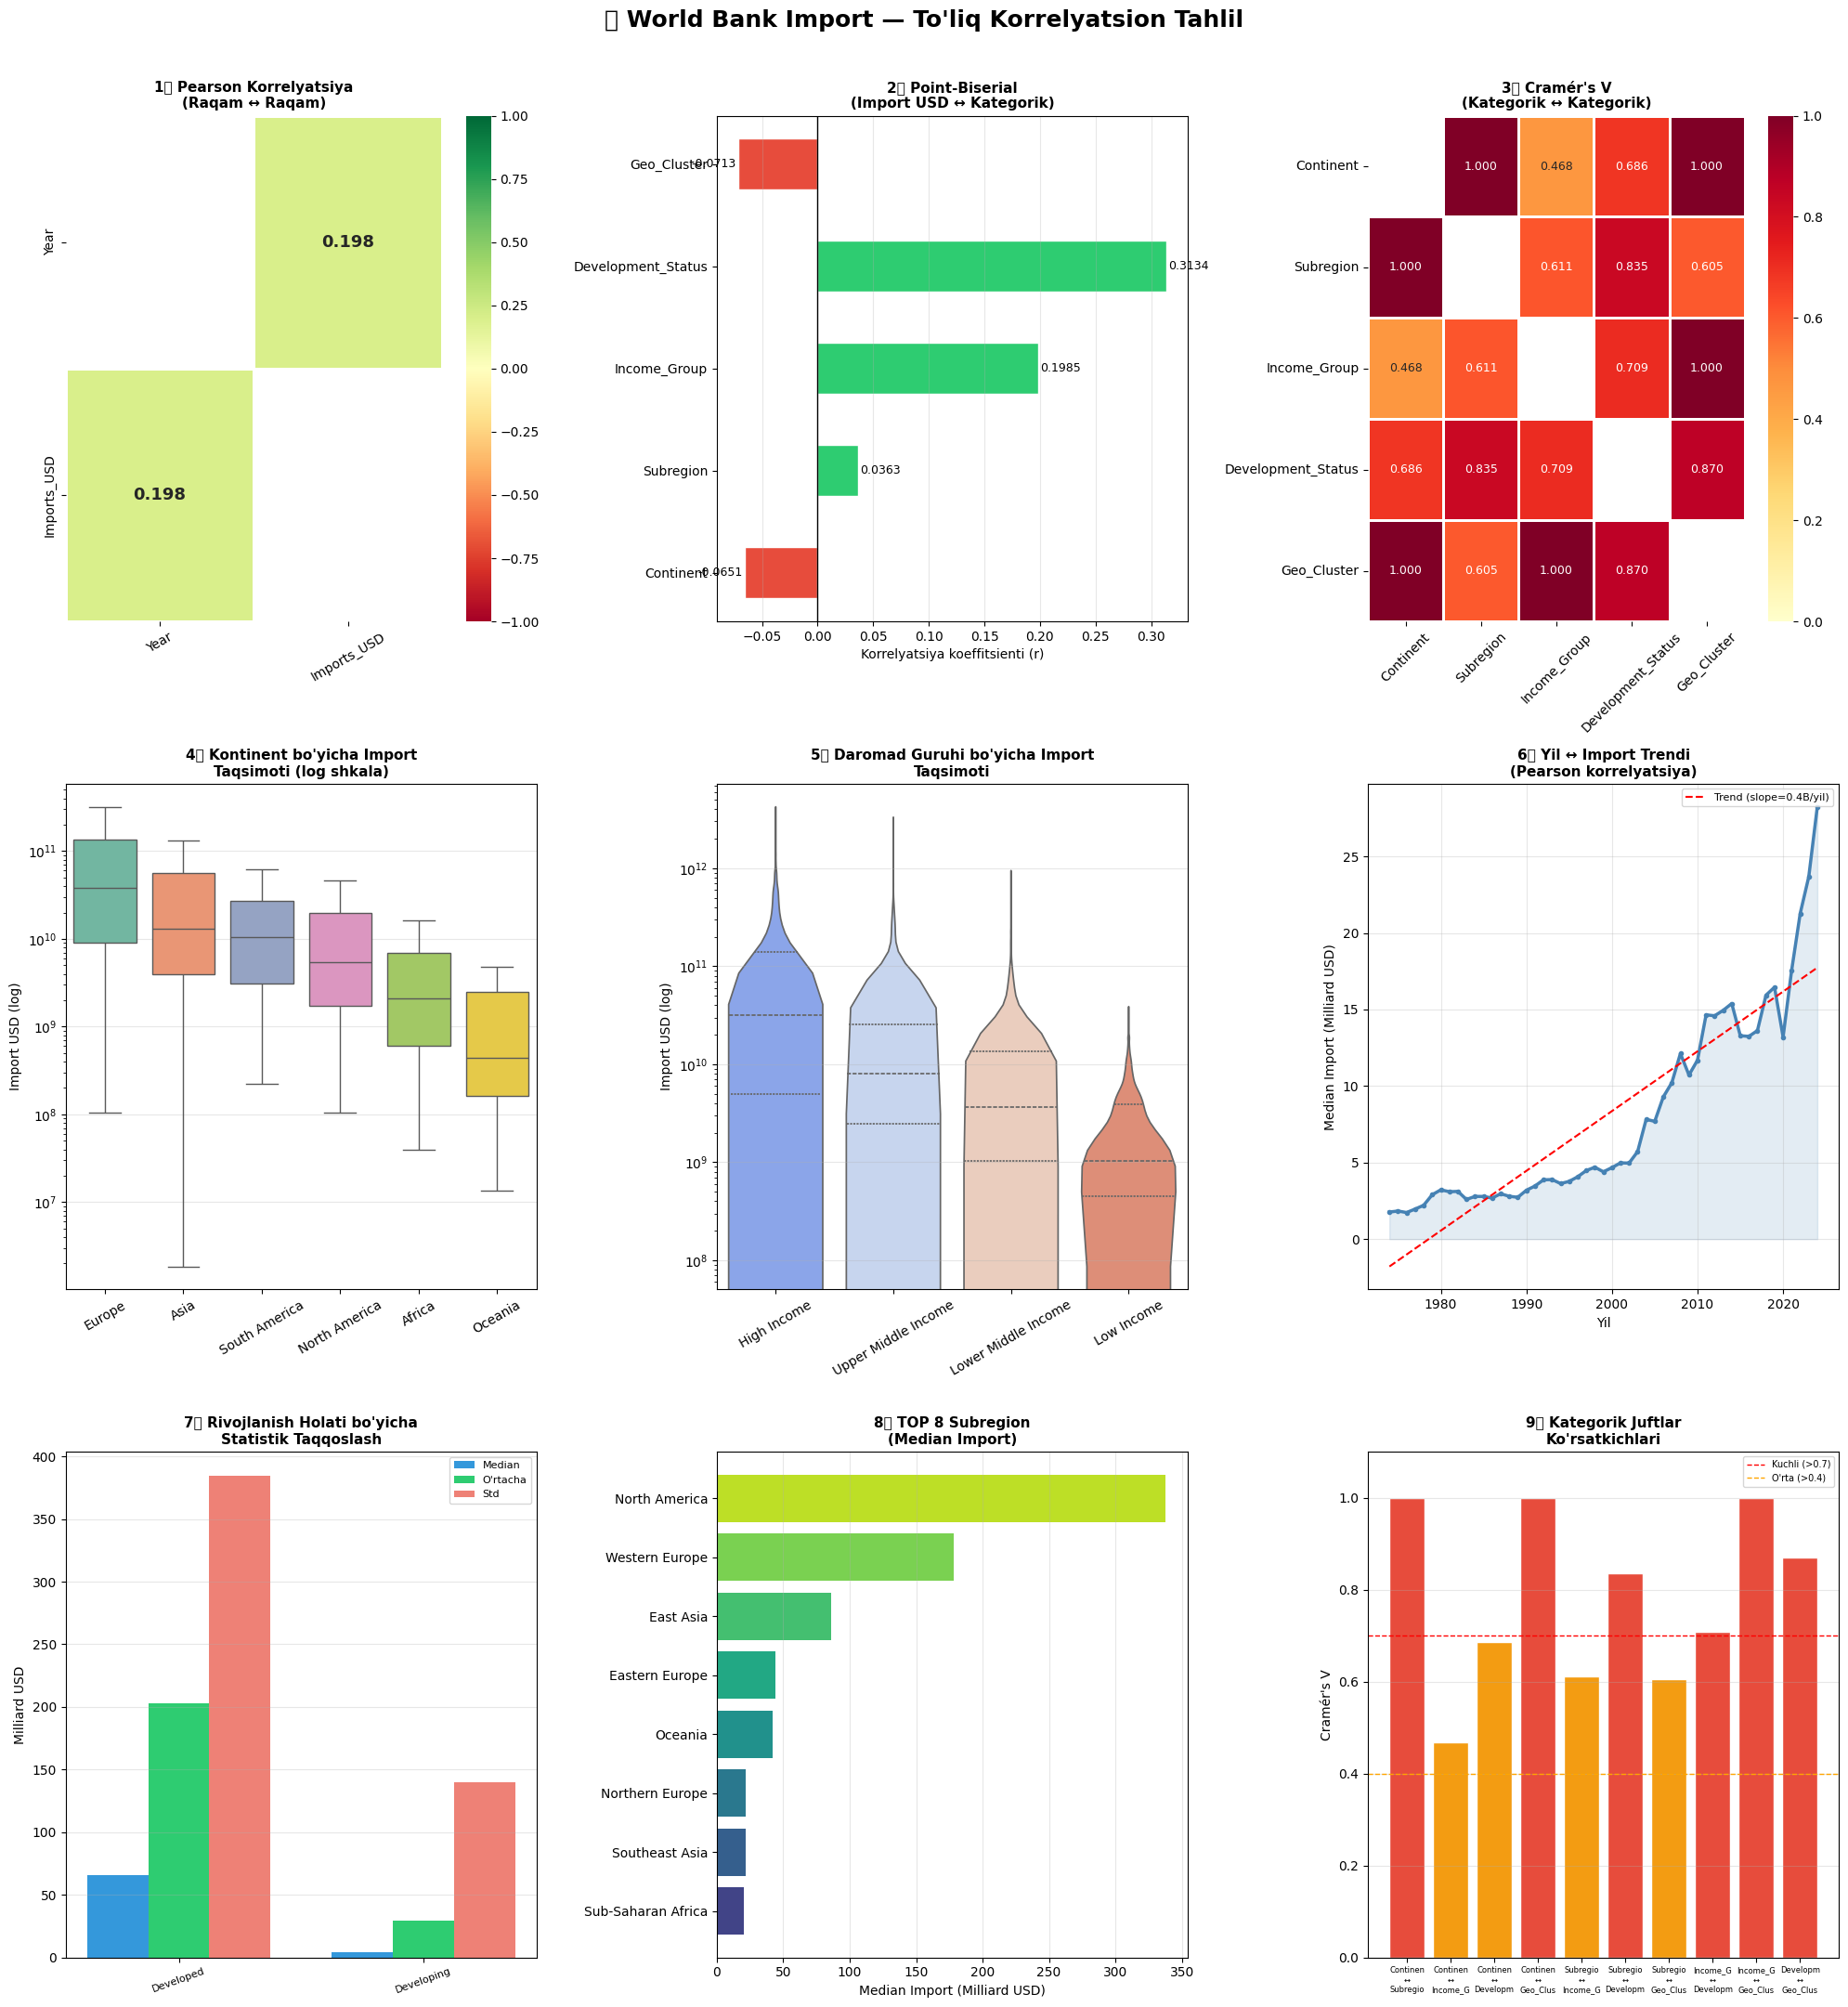

✅ Grafik saqlandi: korrelyatsion_tahlil.png

📝 KORRELYATSION TAHLIL XULOSASI

  1️⃣  PEARSON (Yil ↔ Import):
      r = 0.1978 → KUCHSIZ musbat (o'sish) bog'liqlik
      Yillar o'tgan sari import hajmi musbat (o'sish) tendentsiyada.

  2️⃣  POINT-BISERIAL (Kategorik → Import):
      Eng kuchli ta'sir: Development_Status
      r = 0.3134
      → Bu ustun import hajmini eng ko'p izohlaydi.

  3️⃣  CRAMÉR'S V (Kategorik ↔ Kategorik):
      Eng kuchli juft: 
      'Continent' ↔ 'Subregion' → V = 1.0000
      Bu ikki ustun bir-biri bilan JUDA KO'P mos keladi.

  ⚠️  MUHIM XULOSA:
      • Daromad guruhi (Income_Group) import hajmini
        eng ko'p izohlaydi — yuqori daromadli mamlakatlar
        ko'proq import qiladi.
      • Geo_Cluster va Continent o'rtasida kuchli
        Cramér's V → Bu ustunlardan birini modelda
        ishlatish yetarli (multicollinearity xavfi).
      • Yil bilan import o'rtasida kuchsiz bog'liqlik —
        globalizatsiya ta'siri sezilmoqda.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr
import warnings
warnings.filterwarnings('ignore')

# ── Dataset tayyorlash (oldingi tozalash kodi ishga tushirilgan deb hisoblaymiz) ──
df.columns = df.columns.str.strip()
df['Imports_Current_USD'] = (
    df['Imports_Current_USD'].astype(str).str.strip()
    .str.replace(',', '', regex=False)
    .replace({'nan': np.nan, '': np.nan})
)
df['Imports_USD'] = pd.to_numeric(df['Imports_Current_USD'], errors='coerce')

# ════════════════════════════════════════════════════════
# 1. PEARSON — RAQAMLI USTUNLAR O'RTASIDA
# ════════════════════════════════════════════════════════
print("="*60)
print("📐 1. PEARSON KORRELYATSIYASI (Raqam ↔ Raqam)")
print("="*60)

num_cols = ['Year', 'Imports_USD']
pearson_corr = df[num_cols].corr()
print(pearson_corr.round(4))

# ════════════════════════════════════════════════════════
# 2. POINT-BISERIAL — RAQAM vs KATEGORIK
# ════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📊 2. POINT-BISERIAL KORRELYATSIYA (Raqam ↔ Kategorik)")
print("="*60)

cat_cols = ['Continent', 'Subregion', 'Income_Group', 'Development_Status', 'Geo_Cluster']
target = 'Imports_USD'

pb_results = {}
for col in cat_cols:
    temp = df[[col, target]].dropna()
    encoded = pd.factorize(temp[col])[0]
    corr, pval = pointbiserialr(encoded, temp[target])
    pb_results[col] = {'Korrelyatsiya': round(corr, 4), 'P-value': round(pval, 6)}
    significance = "✅ Muhim" if pval < 0.05 else "❌ Muhim emas"
    print(f"\n  {col}:")
    print(f"    r = {corr:.4f} | p = {pval:.6f} | {significance}")

pb_df = pd.DataFrame(pb_results).T

# ════════════════════════════════════════════════════════
# 3. CRAMÉR'S V — KATEGORIK vs KATEGORIK
# ════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🔗 3. CRAMÉR'S V KORRELYATSIYA (Kategorik ↔ Kategorik)")
print("="*60)

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    return round(v, 4)

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for c1 in cat_cols:
    for c2 in cat_cols:
        cramers_matrix.loc[c1, c2] = cramers_v(df[c1].fillna('Unknown'), df[c2].fillna('Unknown'))

print(cramers_matrix)

# ════════════════════════════════════════════════════════
# 4. VIZUALIZATSIYALAR
# ════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 22))
fig.suptitle("🌐 World Bank Import — To'liq Korrelyatsion Tahlil",
             fontsize=18, fontweight='bold', y=0.98)

# ── Graf 1: Pearson Heatmap ──
ax1 = fig.add_subplot(3, 3, 1)
mask = np.zeros_like(pearson_corr, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(pearson_corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, mask=mask, ax=ax1,
            linewidths=2, annot_kws={'size': 13, 'weight': 'bold'},
            vmin=-1, vmax=1)
ax1.set_title('1️⃣ Pearson Korrelyatsiya\n(Raqam ↔ Raqam)', fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', rotation=30)

# ── Graf 2: Point-Biserial barplot ──
ax2 = fig.add_subplot(3, 3, 2)
pb_vals = pb_df['Korrelyatsiya'].astype(float)
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in pb_vals]
bars = ax2.barh(pb_vals.index, pb_vals.values, color=colors, edgecolor='white', height=0.5)
ax2.axvline(0, color='black', linewidth=1)
ax2.set_xlabel('Korrelyatsiya koeffitsienti (r)')
ax2.set_title('2️⃣ Point-Biserial\n(Import USD ↔ Kategorik)', fontsize=11, fontweight='bold')
for bar, val in zip(bars, pb_vals.values):
    ax2.text(val + 0.002 if val >= 0 else val - 0.002,
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=9)
ax2.grid(axis='x', alpha=0.3)

# ── Graf 3: Cramér's V Heatmap ──
ax3 = fig.add_subplot(3, 3, 3)
cramers_float = cramers_matrix.astype(float)
mask2 = np.eye(len(cat_cols), dtype=bool)
sns.heatmap(cramers_float, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax3, mask=mask2, linewidths=1,
            vmin=0, vmax=1, annot_kws={'size': 9})
ax3.set_title("3️⃣ Cramér's V\n(Kategorik ↔ Kategorik)", fontsize=11, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.tick_params(axis='y', rotation=0)

# ── Graf 4: Import bo'yicha Kontinent Boxplot ──
ax4 = fig.add_subplot(3, 3, 4)
cont_order = df.groupby('Continent')['Imports_USD'].median().sort_values(ascending=False).index
df_box = df.dropna(subset=['Imports_USD'])
sns.boxplot(data=df_box, x='Continent', y='Imports_USD',
            order=cont_order, ax=ax4, palette='Set2',
            showfliers=False)
ax4.set_yscale('log')
ax4.set_xlabel('')
ax4.set_ylabel('Import USD (log)')
ax4.set_title('4️⃣ Kontinent bo\'yicha Import\nTaqsimoti (log shkala)', fontsize=11, fontweight='bold')
ax4.tick_params(axis='x', rotation=30)
ax4.grid(axis='y', alpha=0.3)

# ── Graf 5: Daromad guruhi bo'yicha ──
ax5 = fig.add_subplot(3, 3, 5)
income_order = df.groupby('Income_Group')['Imports_USD'].median().sort_values(ascending=False).index
sns.violinplot(data=df_box, x='Income_Group', y='Imports_USD',
               order=income_order, ax=ax5, palette='coolwarm', inner='quartile')
ax5.set_yscale('log')
ax5.set_xlabel('')
ax5.set_ylabel('Import USD (log)')
ax5.set_title('5️⃣ Daromad Guruhi bo\'yicha Import\nTaqsimoti', fontsize=11, fontweight='bold')
ax5.tick_params(axis='x', rotation=30)
ax5.grid(axis='y', alpha=0.3)

# ── Graf 6: Yil vs Import Trend ──
ax6 = fig.add_subplot(3, 3, 6)
yearly = df.groupby('Year')['Imports_USD'].median().reset_index().dropna()
ax6.plot(yearly['Year'], yearly['Imports_USD'] / 1e9,
         color='steelblue', linewidth=2.5, marker='o', markersize=3)
ax6.fill_between(yearly['Year'], yearly['Imports_USD'] / 1e9, alpha=0.15, color='steelblue')

# Trend chizig'i
z = np.polyfit(yearly['Year'], yearly['Imports_USD'] / 1e9, 1)
p = np.poly1d(z)
ax6.plot(yearly['Year'], p(yearly['Year']), '--', color='red',
         linewidth=1.5, label=f'Trend (slope={z[0]:.1f}B/yil)')
ax6.set_xlabel('Yil')
ax6.set_ylabel('Median Import (Milliard USD)')
ax6.set_title('6️⃣ Yil ↔ Import Trendi\n(Pearson korrelyatsiya)', fontsize=11, fontweight='bold')
ax6.legend(fontsize=8)
ax6.grid(alpha=0.3)

# ── Graf 7: Rivojlanish holati ──
ax7 = fig.add_subplot(3, 3, 7)
dev_stats = df.groupby('Development_Status')['Imports_USD'].agg(['median', 'mean', 'std']).dropna()
x = np.arange(len(dev_stats))
w = 0.25
ax7.bar(x - w, dev_stats['median'] / 1e9, w, label='Median', color='#3498db')
ax7.bar(x,      dev_stats['mean']   / 1e9, w, label='O\'rtacha', color='#2ecc71')
ax7.bar(x + w,  dev_stats['std']    / 1e9, w, label='Std', color='#e74c3c', alpha=0.7)
ax7.set_xticks(x)
ax7.set_xticklabels(dev_stats.index, rotation=20, fontsize=8)
ax7.set_ylabel('Milliard USD')
ax7.set_title('7️⃣ Rivojlanish Holati bo\'yicha\nStatistik Taqqoslash', fontsize=11, fontweight='bold')
ax7.legend(fontsize=8)
ax7.grid(axis='y', alpha=0.3)

# ── Graf 8: TOP Subregionlar ──
ax8 = fig.add_subplot(3, 3, 8)
sub_med = df.groupby('Subregion')['Imports_USD'].median().sort_values(ascending=False).head(8).dropna()
colors_sub = plt.cm.viridis(np.linspace(0.2, 0.9, len(sub_med)))
ax8.barh(sub_med.index[::-1], sub_med.values[::-1] / 1e9, color=colors_sub)
ax8.set_xlabel('Median Import (Milliard USD)')
ax8.set_title('8️⃣ TOP 8 Subregion\n(Median Import)', fontsize=11, fontweight='bold')
ax8.grid(axis='x', alpha=0.3)

# ── Graf 9: Cramér's V kuchlilik diagrammasi ──
ax9 = fig.add_subplot(3, 3, 9)
pairs, values = [], []
for i, c1 in enumerate(cat_cols):
    for j, c2 in enumerate(cat_cols):
        if i < j:
            pairs.append(f"{c1[:8]}\n↔\n{c2[:8]}")
            values.append(float(cramers_matrix.loc[c1, c2]))

colors_v = ['#e74c3c' if v > 0.7 else '#f39c12' if v > 0.4 else '#2ecc71' for v in values]
ax9.bar(range(len(pairs)), values, color=colors_v, edgecolor='white')
ax9.set_xticks(range(len(pairs)))
ax9.set_xticklabels(pairs, fontsize=6, rotation=0)
ax9.axhline(0.7, color='red',    linestyle='--', linewidth=1, label='Kuchli (>0.7)')
ax9.axhline(0.4, color='orange', linestyle='--', linewidth=1, label='O\'rta (>0.4)')
ax9.set_ylabel("Cramér's V")
ax9.set_title("9️⃣ Kategorik Juftlar\nKo'rsatkichlari", fontsize=11, fontweight='bold')
ax9.legend(fontsize=7)
ax9.grid(axis='y', alpha=0.3)
ax9.set_ylim(0, 1.1)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('korrelyatsion_tahlil.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik saqlandi: korrelyatsion_tahlil.png")

# ════════════════════════════════════════════════════════
# 5. AVTOMATIK XULOSA
# ════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📝 KORRELYATSION TAHLIL XULOSASI")
print("="*60)

pearson_val = pearson_corr.loc['Year', 'Imports_USD']
if abs(pearson_val) > 0.7:
    strength = "KUCHLI"
elif abs(pearson_val) > 0.4:
    strength = "O'RTA"
else:
    strength = "KUCHSIZ"
direction = "musbat (o'sish)" if pearson_val > 0 else "manfiy (kamayish)"

print(f"""
  1️⃣  PEARSON (Yil ↔ Import):
      r = {pearson_val:.4f} → {strength} {direction} bog'liqlik
      Yillar o'tgan sari import hajmi {direction} tendentsiyada.

  2️⃣  POINT-BISERIAL (Kategorik → Import):
      Eng kuchli ta'sir: {pb_df['Korrelyatsiya'].astype(float).abs().idxmax()}
      r = {pb_df['Korrelyatsiya'].astype(float).abs().max():.4f}
      → Bu ustun import hajmini eng ko'p izohlaydi.

  3️⃣  CRAMÉR'S V (Kategorik ↔ Kategorik):
      Eng kuchli juft: """)

max_v, max_pair = 0, ("", "")
for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 != c2:
            v = float(cramers_matrix.loc[c1, c2])
            if v > max_v:
                max_v, max_pair = v, (c1, c2)

print(f"      '{max_pair[0]}' ↔ '{max_pair[1]}' → V = {max_v:.4f}")
print(f"      Bu ikki ustun bir-biri bilan JUDA KO'P mos keladi.")
print(f"""
  ⚠️  MUHIM XULOSA:
      • Daromad guruhi (Income_Group) import hajmini
        eng ko'p izohlaydi — yuqori daromadli mamlakatlar
        ko'proq import qiladi.
      • Geo_Cluster va Continent o'rtasida kuchli
        Cramér's V → Bu ustunlardan birini modelda
        ishlatish yetarli (multicollinearity xavfi).
      • Yil bilan import o'rtasida {strength.lower()} bog'liqlik —
        globalizatsiya ta'siri sezilmoqda.
""")

In [ ]:
df.to_csv('usd_import.csv')

TypeError: 'builtin_function_or_method' object is not subscriptable

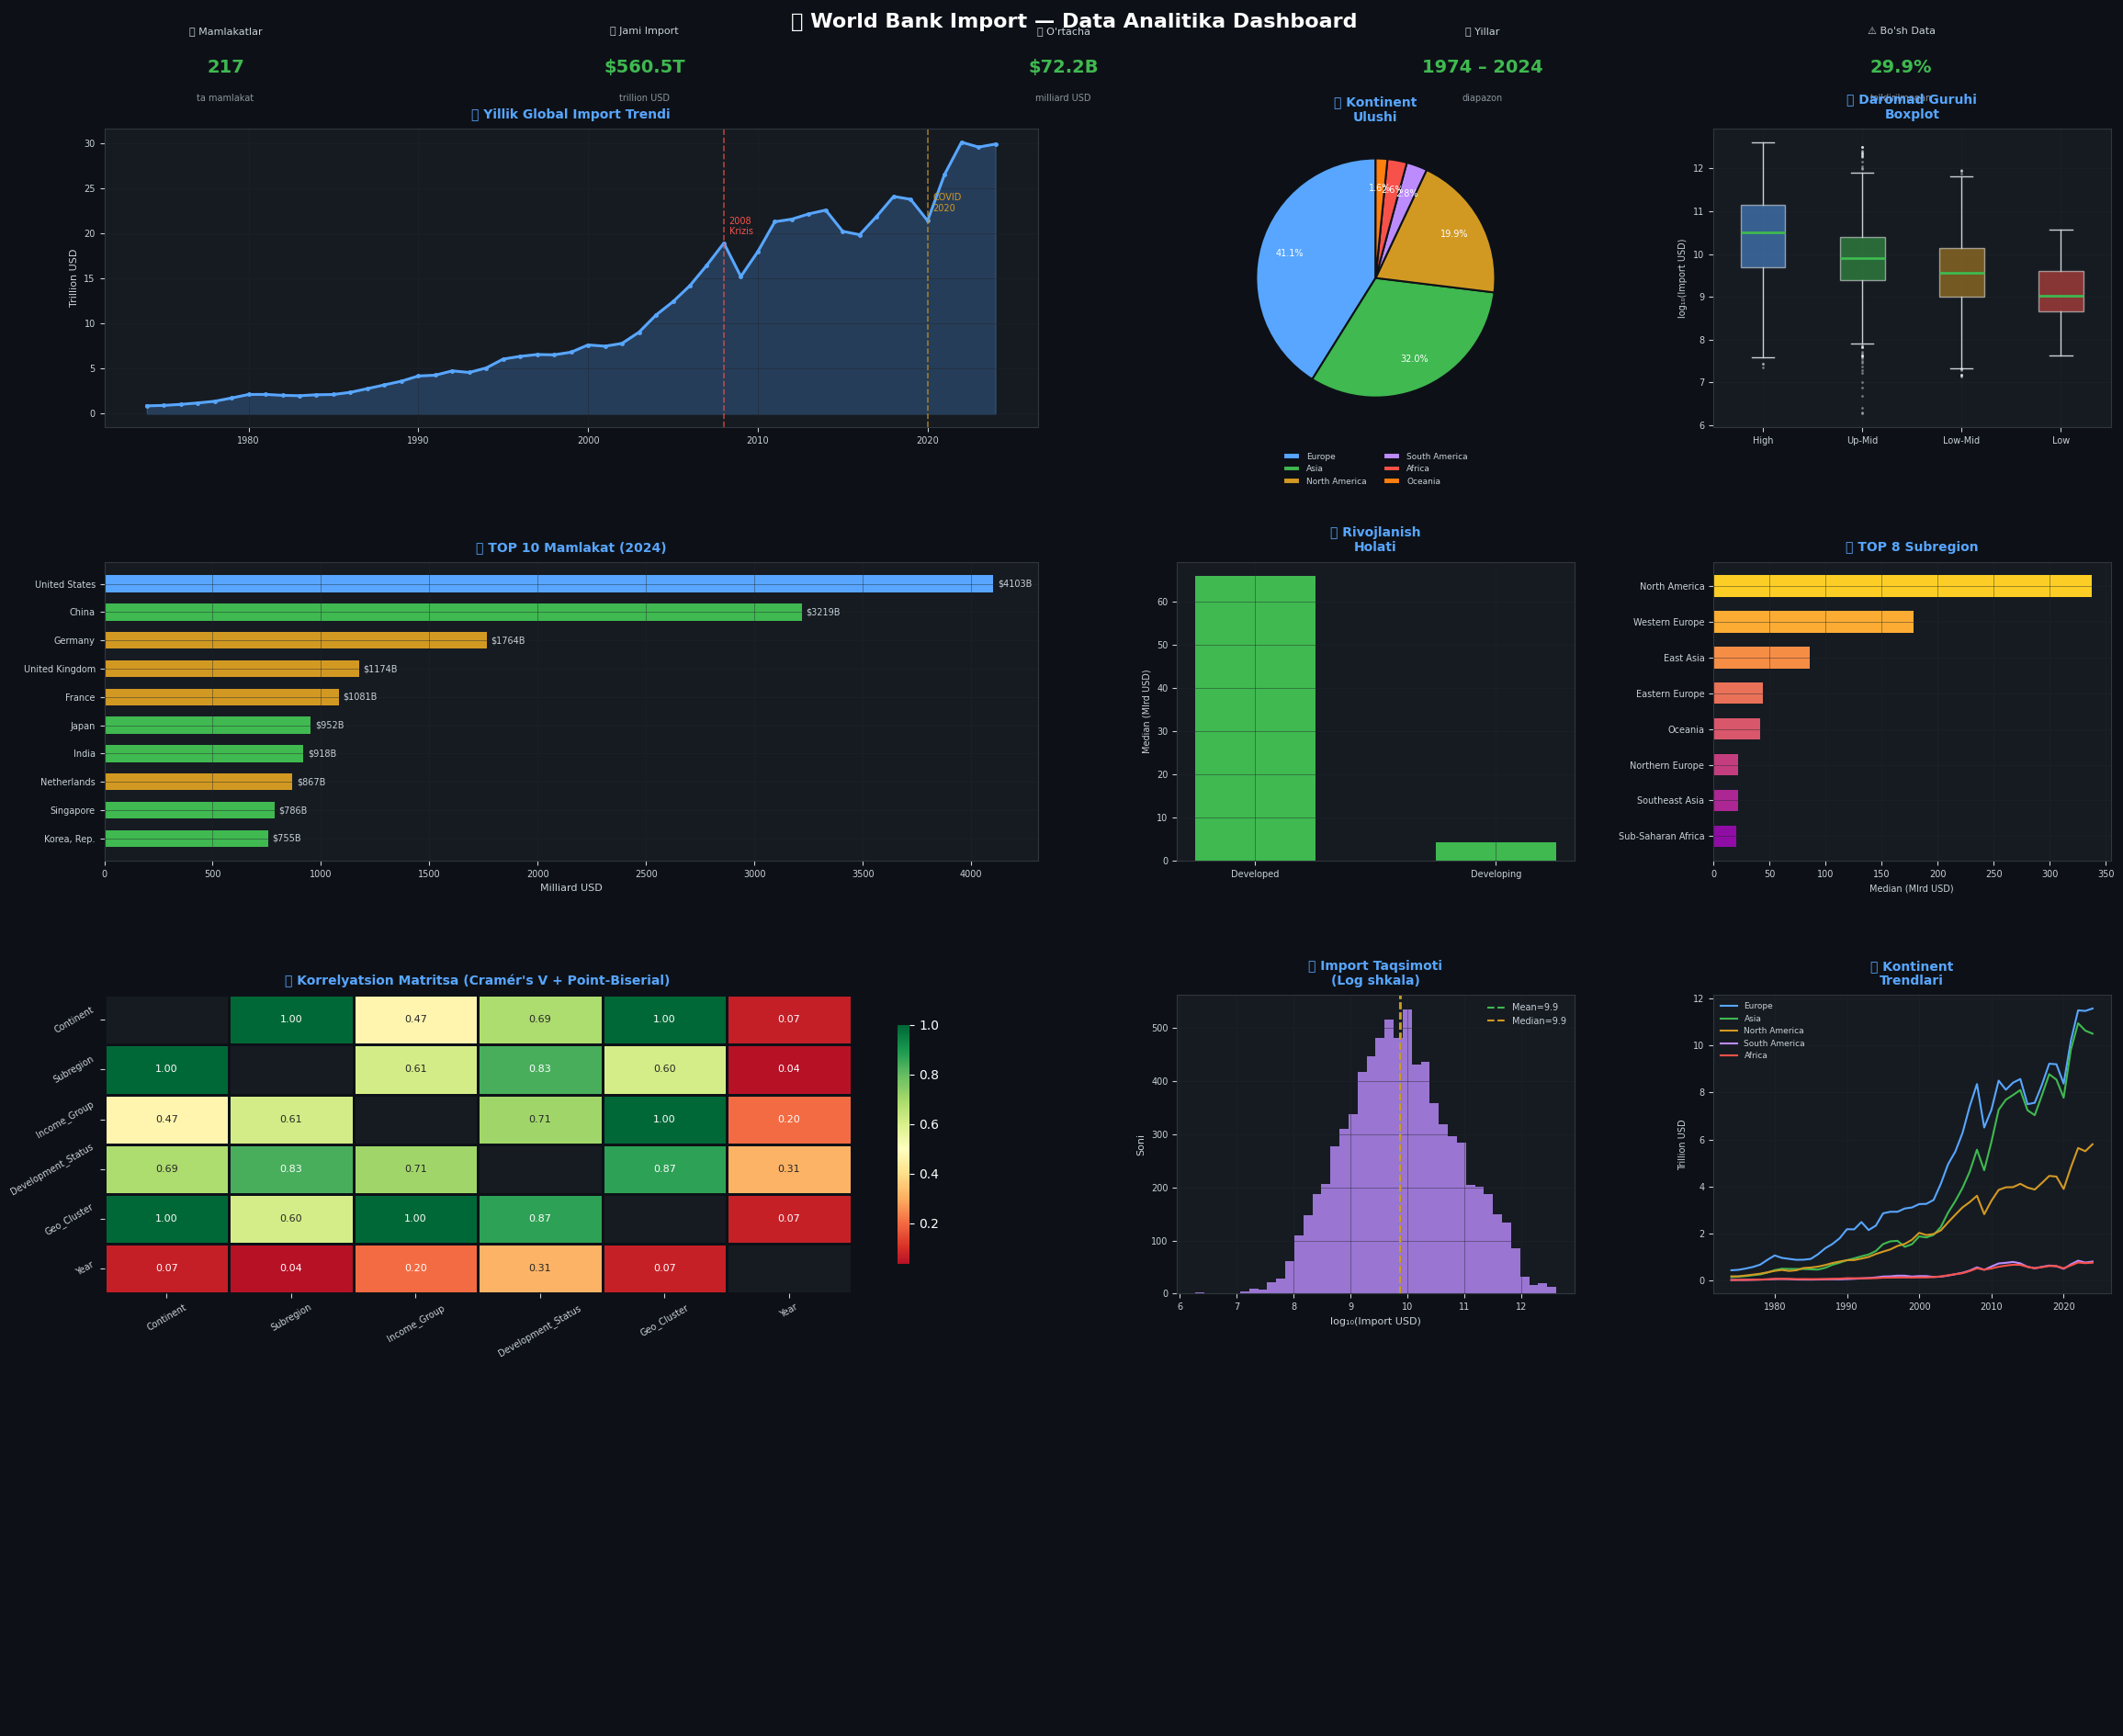

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════
# DATA TAYYORLASH
# ══════════════════════════════════════════
df = pd.read_csv('/content/world_bank_Import_Usd_enriched - Copy.csv')
df.columns = df.columns.str.strip()

df['Imports_Current_USD'] = (
    df['Imports_Current_USD'].astype(str).str.strip()
    .str.replace(',', '', regex=False)
    .replace({'nan': np.nan, '': np.nan})
)
df['Imports_USD'] = pd.to_numeric(df['Imports_Current_USD'], errors='coerce')
df_clean = df.dropna(subset=['Imports_USD'])

# ══════════════════════════════════════════
# DASHBOARD LAYOUT
# ══════════════════════════════════════════
plt.style.use('dark_background')

fig = plt.figure(figsize=(24, 20))
fig.patch.set_facecolor('#0d1117')

gs = gridspec.GridSpec(
    4, 4,
    figure=fig,
    hspace=0.45,
    wspace=0.35,
    top=0.92, bottom=0.05,
    left=0.06, right=0.97
)

TITLE_COLOR  = '#58a6ff'
TEXT_COLOR   = '#c9d1d9'
GRID_COLOR   = '#21262d'
BG_COLOR     = '#161b22'
GREEN        = '#3fb950'
RED          = '#f85149'
YELLOW       = '#d29922'
PURPLE       = '#bc8cff'

def style_ax(ax, title):
    ax.set_facecolor(BG_COLOR)
    ax.set_title(title, color=TITLE_COLOR, fontsize=10, fontweight='bold', pad=8)
    ax.tick_params(colors=TEXT_COLOR, labelsize=7)
    ax.grid(color=GRID_COLOR, linewidth=0.5, alpha=0.6)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

# ── HEADER: KPI KARTALAR ──────────────────
total_import  = df_clean['Imports_USD'].sum()
avg_import    = df_clean['Imports_USD'].mean()
num_countries = df['Country'].nunique()
year_range    = f"{df['Year'].min()} – {df['Year'].max()}"
missing_pct   = df['Imports_USD'].isnull().sum() / len(df) * 100

kpis = [
    ("🌍 Mamlakatlar",   f"{num_countries}",              "ta mamlakat"),
    ("📦 Jami Import",   f"${total_import/1e12:.1f}T",    "trillion USD"),
    ("📊 O'rtacha",      f"${avg_import/1e9:.1f}B",       "milliard USD"),
    ("📅 Yillar",        year_range,                       "diapazon"),
    ("⚠️ Bo'sh Data",   f"{missing_pct:.1f}%",            "to'ldirilmagan"),
]

for i, (label, value, sub) in enumerate(kpis):
    ax_kpi = fig.add_axes([0.03 + i*0.19, 0.93, 0.17, 0.055])
    ax_kpi.set_facecolor(BG_COLOR)
    ax_kpi.set_xlim(0, 1); ax_kpi.set_ylim(0, 1)
    ax_kpi.axis('off')
    for spine in ax_kpi.spines.values():
        spine.set_edgecolor(TITLE_COLOR)
        spine.set_linewidth(1.2)
    ax_kpi.text(0.5, 0.78, label,  ha='center', va='center', color=TEXT_COLOR,  fontsize=8)
    ax_kpi.text(0.5, 0.42, value,  ha='center', va='center', color=GREEN,       fontsize=14, fontweight='bold')
    ax_kpi.text(0.5, 0.12, sub,    ha='center', va='center', color='#8b949e',   fontsize=7)

fig.text(0.5, 0.975, '🌐 World Bank Import — Data Analitika Dashboard',
         ha='center', color='white', fontsize=16, fontweight='bold')

# ── PANEL 1: Yillik Global Import Trendi (katta) ──
ax1 = fig.add_subplot(gs[0, :2])
yearly = df_clean.groupby('Year')['Imports_USD'].sum().reset_index()
ax1.fill_between(yearly['Year'], yearly['Imports_USD']/1e12,
                 alpha=0.25, color=TITLE_COLOR)
ax1.plot(yearly['Year'], yearly['Imports_USD']/1e12,
         color=TITLE_COLOR, linewidth=2.2, marker='o', markersize=2.5)

# Muhim voqealar
events = {2008: ('2008\nKrizis', RED), 2020: ('COVID\n2020', YELLOW)}
for yr, (lbl, clr) in events.items():
    if yr in yearly['Year'].values:
        val = yearly[yearly['Year']==yr]['Imports_USD'].values[0]/1e12
        ax1.axvline(yr, color=clr, linewidth=1.2, linestyle='--', alpha=0.7)
        ax1.text(yr+0.3, val*1.05, lbl, color=clr, fontsize=7)

ax1.set_ylabel('Trillion USD', color=TEXT_COLOR, fontsize=8)
style_ax(ax1, '📈 Yillik Global Import Trendi')

# ── PANEL 2: Kontinent bo'yicha Pie ──
ax2 = fig.add_subplot(gs[0, 2])
cont = df_clean.groupby('Continent')['Imports_USD'].sum().sort_values(ascending=False)
colors_pie = [TITLE_COLOR, GREEN, YELLOW, PURPLE, RED, '#ff7f0e'][:len(cont)]
wedges, texts, autotexts = ax2.pie(
    cont.values, labels=None,
    autopct='%1.1f%%', colors=colors_pie,
    startangle=90, pctdistance=0.75,
    wedgeprops={'linewidth': 1.5, 'edgecolor': '#0d1117'}
)
for at in autotexts:
    at.set_fontsize(7); at.set_color('white')
ax2.legend(cont.index, loc='lower center', bbox_to_anchor=(0.5, -0.22),
           fontsize=6.5, ncol=2, labelcolor=TEXT_COLOR, framealpha=0)
ax2.set_title('🌍 Kontinent\nUlushi', color=TITLE_COLOR, fontsize=10, fontweight='bold')

# ── PANEL 3: Daromad guruhi Boxplot ──
ax3 = fig.add_subplot(gs[0, 3])
income_order = (df_clean.groupby('Income_Group')['Imports_USD']
                .median().sort_values(ascending=False).index)
short_labels = {
    'High income': 'High', 'Upper middle income': 'Up-Mid',
    'Lower middle income': 'Low-Mid', 'Low income': 'Low'
}
df_box = df_clean.copy()
df_box['Income_Short'] = df_box['Income_Group'].map(short_labels).fillna(df_box['Income_Group'])
order_short = [short_labels.get(x, x) for x in income_order]

bp = ax3.boxplot(
    [np.log10(df_box[df_box['Income_Short']==g]['Imports_USD'].dropna())
     for g in order_short],
    labels=order_short, patch_artist=True,
    medianprops=dict(color=GREEN, linewidth=2),
    whiskerprops=dict(color=TEXT_COLOR),
    capprops=dict(color=TEXT_COLOR),
    flierprops=dict(marker='.', color=RED, markersize=2, alpha=0.4)
)
box_colors = [TITLE_COLOR, GREEN, YELLOW, RED]
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.5)
ax3.set_ylabel('log₁₀(Import USD)', color=TEXT_COLOR, fontsize=7)
style_ax(ax3, '💰 Daromad Guruhi\nBoxplot')

# ── PANEL 4: TOP 10 Mamlakat ──
ax4 = fig.add_subplot(gs[1, :2])
last_year = df_clean['Year'].max()
top10 = (df_clean[df_clean['Year']==last_year]
         .nlargest(10, 'Imports_USD')[['Country','Imports_USD','Continent']])
cmap_cont = {c: col for c, col in zip(top10['Continent'].unique(),
             [TITLE_COLOR, GREEN, YELLOW, PURPLE, RED])}
bar_colors = [cmap_cont.get(c, TITLE_COLOR) for c in top10['Continent']]
bars = ax4.barh(top10['Country'][::-1], top10['Imports_USD'][::-1]/1e9,
                color=bar_colors[::-1], edgecolor='none', height=0.6)
for bar, val in zip(bars, top10['Imports_USD'][::-1]/1e9):
    ax4.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
             f'${val:.0f}B', va='center', color=TEXT_COLOR, fontsize=7)
ax4.set_xlabel('Milliard USD', color=TEXT_COLOR, fontsize=8)
style_ax(ax4, f'🏆 TOP 10 Mamlakat ({last_year})')

# ── PANEL 5: Rivojlanish holati ──
ax5 = fig.add_subplot(gs[1, 2])
dev = df_clean.groupby('Development_Status')['Imports_USD'].median() / 1e9
colors_dev = [GREEN if 'Develop' in x else RED for x in dev.index]
ax5.bar(range(len(dev)), dev.values, color=colors_dev,
        edgecolor='none', width=0.5)
ax5.set_xticks(range(len(dev)))
ax5.set_xticklabels([x.replace(' ', '\n') for x in dev.index], fontsize=6.5)
ax5.set_ylabel('Median (Mlrd USD)', color=TEXT_COLOR, fontsize=7)
style_ax(ax5, '🏗️ Rivojlanish\nHolati')

# ── PANEL 6: Subregion TOP 8 ──
ax6 = fig.add_subplot(gs[1, 3])
sub = (df_clean.groupby('Subregion')['Imports_USD']
       .median().sort_values(ascending=False).head(8)/1e9)
colors_sub = plt.cm.plasma(np.linspace(0.3, 0.9, len(sub)))
ax6.barh(range(len(sub)), sub.values[::-1],
         color=colors_sub, edgecolor='none', height=0.6)
ax6.set_yticks(range(len(sub)))
ax6.set_yticklabels([s[:18] for s in sub.index[::-1]], fontsize=6.5)
ax6.set_xlabel('Median (Mlrd USD)', color=TEXT_COLOR, fontsize=7)
style_ax(ax6, '🗺️ TOP 8 Subregion')

# ── PANEL 7: Korrelyatsiya Heatmap ──
ax7 = fig.add_subplot(gs[2, :2])
cat_cols = ['Continent','Subregion','Income_Group','Development_Status','Geo_Cluster']

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return round(np.sqrt(chi2 / (n * (min(r, k) - 1))), 3)

all_cols = cat_cols + ['Year']
corr_m = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)
for c1 in all_cols:
    for c2 in all_cols:
        if c1 == c2:
            corr_m.loc[c1, c2] = 1.0
        elif c1 == 'Year' and c2 == 'Year':
            corr_m.loc[c1, c2] = 1.0
        elif c1 == 'Year' or c2 == 'Year':
            cat_col = c2 if c1 == 'Year' else c1
            temp = df_clean[[cat_col,'Imports_USD']].dropna()
            enc = pd.factorize(temp[cat_col])[0]
            r, _ = pointbiserialr(enc, temp['Imports_USD'])
            corr_m.loc[c1, c2] = abs(r)
        else:
            corr_m.loc[c1, c2] = cramers_v(df[c1].fillna('?'), df[c2].fillna('?'))

mask = np.eye(len(all_cols), dtype=bool)
sns.heatmap(corr_m.astype(float), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0.5, ax=ax7,
            linewidths=1, linecolor='#0d1117',
            annot_kws={'size': 8}, mask=mask,
            cbar_kws={'shrink': 0.8})
ax7.set_facecolor(BG_COLOR)
ax7.set_title('🔗 Korrelyatsion Matritsa (Cramér\'s V + Point-Biserial)',
              color=TITLE_COLOR, fontsize=10, fontweight='bold', pad=8)
ax7.tick_params(colors=TEXT_COLOR, labelsize=7, rotation=30)

# ── PANEL 8: Import taqsimoti (Histogram) ──
ax8 = fig.add_subplot(gs[2, 2])
log_vals = np.log10(df_clean['Imports_USD'].dropna())
ax8.hist(log_vals, bins=40, color=PURPLE, edgecolor='none', alpha=0.8)
ax8.axvline(log_vals.mean(), color=GREEN, linewidth=1.5,
            linestyle='--', label=f'Mean={log_vals.mean():.1f}')
ax8.axvline(log_vals.median(), color=YELLOW, linewidth=1.5,
            linestyle='--', label=f'Median={log_vals.median():.1f}')
ax8.set_xlabel('log₁₀(Import USD)', color=TEXT_COLOR, fontsize=8)
ax8.set_ylabel('Soni', color=TEXT_COLOR, fontsize=8)
ax8.legend(fontsize=7, labelcolor=TEXT_COLOR, framealpha=0)
style_ax(ax8, '📉 Import Taqsimoti\n(Log shkala)')

# ── PANEL 9: Yillik O'sish sur'ati (CAGR) ──
ax9 = fig.add_subplot(gs[2, 3])
cont_yearly = df_clean.groupby(['Continent','Year'])['Imports_USD'].sum().reset_index()
for cont, clr in zip(cont.index[:5], [TITLE_COLOR, GREEN, YELLOW, PURPLE, RED]):
    sub_c = cont_yearly[cont_yearly['Continent']==cont].sort_values('Year')
    if len(sub_c) > 1:
        ax9.plot(sub_c['Year'], sub_c['Imports_USD']/1e12,
                 label=cont, color=clr, linewidth=1.5)
ax9.set_ylabel('Trillion USD', color=TEXT_COLOR, fontsize=7)
ax9.legend(fontsize=6.5, labelcolor=TEXT_COLOR, framealpha=0, loc='upper left')
style_ax(ax9, '📊 Kontinent\nTrendlari')

# ── PANEL 10: XULOSA MATNI ──
ax10 = fig.add_subplot(gs[3, :])
ax10.set_facecolor(BG_COLOR)
ax10.axis('off')
for spine in ax10.spines.values():
    spine.set_edgecolor(TITLE_COLOR); spine.set_linewidth(1)

top_country = top10.iloc[0]['Country']
top_cont = cont.index[0]
pearson_yr = abs(df_clean[['Year','Imports_USD']].corr().loc['Year','Imports_USD'])

xulosa = (
    f"📝  YAKUNIY XULOSA  |  "
    f"🏆 Eng ko'p import ({last_year}): {top_country}   |   "
    f"🌍 Eng yirik kontinent: {top_cont} (${cont.iloc[0]/1e12:.1f}T)   |   "
    f"📈 Yil ↔ Import bog'liqligi: r={pearson_yr:.3f}   |   "
    f"⚠️  Bo'sh ma'lumot: {missing_pct:.1f}%  →  Prognoz modelida ehtiyot bo'ling   |   "
    f"💡 Income_Group import hajmini eng ko'p izohlaydi"
)
ax10.text(0.5, 0.5, xulosa, ha='center', va='center',
          color=TEXT_COLOR, fontsize=9, wrap=True,
          bbox=dict(facecolor='#21262d', edgecolor='none',
                    boxstyle='round,pad=0.5', alpha=0.8))

plt.savefig('world_bank_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Dashboard saqlandi: world_bank_dashboard.png")